# Proyecto Innovador IA 1 - Problematic use of internet in children

## 1. Introducción y Configuración

Basados en los requerimientos del proyecto y nuestro análisis inicial, se han definido las siguientes estrategias clave para abordar el problema de predicción del uso problemático de internet en niños:

1.  **Ingeniería de Características:** Extracción de datos estadísticos de las series temporales (Parquet) y normalización por edad de los datos tabulares.
2.  **Imputación:** Uso de `KNNImputer` para manejar los bloques masivos de datos faltantes.
3.  **Validación Cruzada y Aumentación:** Implementación de `RepeatedStratifiedKFold` junto con aumentación de datos (ruido y sobremuestreo) para construir un modelo resistente al *overfitting*.
4.  **Optimización QWK:** Enfoque en regresión (prediciendo `PCIAT-PCIAT_Total`) y optimización matemática de umbrales para maximizar la métrica QWK.

In [1]:
# instalar lightgbm, tqdm
!pip install lightgbm tqdm

In [2]:
# --- 1. Importaciones de Librerías ---
# Esta celda contiene todas las librerías necesarias para el pipeline.

# Manejo de datos y cómputo
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y FE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

# Modelado
import lightgbm as lgb
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Optimización
from scipy.optimize import minimize

# Utilitarios
import os
from tqdm import tqdm
from pathlib import Path
import warnings
import random

# --- Configuración del Entorno ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # Mostrar todas las columnas

# Función de siembra para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

## 2. Carga de Datos y Estrategia de Objetivo

Cargamos los datos tabulares. Se definen variables importantes para el manejo de los datos:
* `DATA_DIR`: Carpeta en donde se encuentran los datos.
* `TARGET`: El *score* numérico (`PCIAT-PCIAT_Total`). **Este es el objetivo de nuestra regresión.**
* `SII_TARGET`: La clase ordinal (`sii`). **Este SÓLO se usará para la estratificación de CV y la métrica QWK final.**
* `ID_COL`: La columna de identificación.

---
#### **Importar datasets**

In [3]:
# --- 2. Carga de Datos Tabulares ---
# Definimos la ruta y cargamos los archivos CSV principales.

# Define la ruta donde se encuentran los datos
DATA_DIR = Path('./data')

# Variables estratégicas
TARGET = 'PCIAT-PCIAT_Total'
SII_TARGET = 'sii'
ID_COL = 'id'

# Se cargan los datos de los archivos CSV
train_csv = pd.read_csv(DATA_DIR / 'train.csv')
test_csv = pd.read_csv(DATA_DIR / 'test.csv')

print(f"train.csv cargado. Shape: {train_csv.shape}")
print(f"test.csv cargado. Shape: {test_csv.shape}")

train.csv cargado. Shape: (3960, 82)
test.csv cargado. Shape: (20, 59)


## 3. EDA Inicial y Prevención de Fuga de Datos (Data Leakage)

Antes de realizar cualquier análisis, debemos identificar y aislar cualquier columna que pueda causar **fuga de datos (data leakage)**. Del análisis realizado en la primera entrega, la información del reto en Kaggle y del conocimiento del negicio sabemos que el *target* (`sii`) se deriva del *score* total del cuestionario (`PCIAT-PCIAT_Total`).

**Nuestra hipótesis es:** El `train.csv` contiene las respuestas a las preguntas individuales (ej. `PCIAT-PCIAT_01`, `PCIAT-PCIAT_02`, etc.) que se usan para calcular el *score* total. Estas columnas **no están disponibles** en el *test set*, por lo tanto, usarlas en el entrenamiento es una fuga de datos.

Vamos a verificar esta hipótesis comparando las columnas de `train` y `test`.

In [4]:
# --- 3.1 Identificación de Columnas con Fuga de Datos ---

# Comparar los conjuntos de columnas para encontrar diferencias
train_cols = set(train_csv.columns)
test_cols = set(test_csv.columns)

cols_solo_en_train = train_cols.difference(test_cols)

print(f"Total de columnas en 'train': {len(train_cols)}")
print(f"Total de columnas en 'test': {len(test_cols)}")
print("\nColumnas que están en 'train' pero NO en 'test':")
print(cols_solo_en_train)

# --- 3.2 Conclusión y Aislamiento ---

# Identificamos las columnas 'leaker' (todas las de PCIAT y SDS)
# (Excluimos nuestros dos targets de la lista de 'features')
leaker_cols = [
    col for col in cols_solo_en_train 
    if col not in [TARGET, SII_TARGET]
]

print(f"\nSe identificaron {len(leaker_cols)} columnas con fuga de datos.")
print(f"Columnas a eliminar: {leaker_cols}")

# --- 3.3 Creación de DataFrames Limpios ---

# Definimos nuestras features como las columnas de 'test' (menos el ID)
# Esta es la lista "segura" de features
FEATURES = [col for col in test_csv.columns if col != ID_COL]

# Filtramos 'train' para que solo contenga lo que necesitamos
# Esto previene que usemos los 'leakers' accidentalmente
train = train_csv[[ID_COL] + FEATURES + [TARGET, SII_TARGET]]

# Se renombra test por consistencia
test = test_csv

print("\n--- DataFrames después de la limpieza de 'leakers' ---")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Número de features: {len(FEATURES)}")

Total de columnas en 'train': 82
Total de columnas en 'test': 59

Columnas que están en 'train' pero NO en 'test':
{'PCIAT-PCIAT_03', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_Total', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_15', 'sii', 'PCIAT-Season', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_09'}

Se identificaron 21 columnas con fuga de datos.
Columnas a eliminar: ['PCIAT-PCIAT_03', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_15', 'PCIAT-Season', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_09']

--- DataFrames después de la lim

## 4. EDA: Análisis de Valores Nulos

Realizaremos un análisis cuantitativo. Agruparemos las *features* según su porcentaje de datos faltantes. Esto nos dirá qué columnas son "usables", cuáles necesitan "imputación" y cuáles son "casi inútiles".

In [5]:
# --- 4.1 EDA: Resumen Cuantitativo de Nulos ---

# 1. Calcular el porcentaje de nulos para nuestras 58 FEATURES
null_pct = (train[FEATURES].isnull().sum() / len(train)) * 100
null_pct = null_pct.sort_values(ascending=False)

# 2. Mostrar un resumen en grupos críticos
print("--- Resumen de Valores Nulos (Porcentaje Faltante) ---")

print("\n[--- GRUPO 1: 'El Desastre' (> 70% de Nulos) ---]")
print(null_pct[null_pct > 70])
print(f"Total de 'features' en este grupo: {len(null_pct[null_pct > 70])}")

print("\n[--- GRUPO 2: 'Bloques Faltantes' (30% - 70% Nulos) ---]")
print(null_pct[(null_pct > 30) & (null_pct <= 70)])
print(f"Total de 'features' en este grupo: {len(null_pct[(null_pct > 30) & (null_pct <= 70)])}")

print("\n[--- GRUPO 3: 'Datos Usables' (< 30% Nulos) ---]")
print(null_pct[(null_pct > 0) & (null_pct <= 30)])
print(f"Total de 'features' en este grupo: {len(null_pct[(null_pct > 0) & (null_pct <= 30)])}")

print("\n[--- GRUPO 4: 'Features de Anclaje' (0% Nulos) ---]")
print(null_pct[null_pct == 0])
print(f"Total de 'features' en este grupo: {len(null_pct[null_pct == 0])}")

print("\n--- Conteo Total ---")
print(f"Total de features analizadas: {len(FEATURES)}")

--- Resumen de Valores Nulos (Porcentaje Faltante) ---

[--- GRUPO 1: 'El Desastre' (> 70% de Nulos) ---]
PAQ_A-Season                    88.005051
PAQ_A-PAQ_A_Total               88.005051
Fitness_Endurance-Time_Mins     81.313131
Fitness_Endurance-Time_Sec      81.313131
Fitness_Endurance-Max_Stage     81.237374
Physical-Waist_Circumference    77.323232
FGC-FGC_GSND_Zone               73.181818
FGC-FGC_GSD_Zone                73.156566
FGC-FGC_GSD                     72.878788
FGC-FGC_GSND                    72.878788
dtype: float64
Total de 'features' en este grupo: 10

[--- GRUPO 2: 'Bloques Faltantes' (30% - 70% Nulos) ---]
Fitness_Endurance-Season      66.969697
PAQ_C-PAQ_C_Total             56.540404
PAQ_C-Season                  56.540404
BIA-BIA_DEE                   49.722222
BIA-BIA_BMC                   49.722222
BIA-BIA_BMI                   49.722222
BIA-BIA_BMR                   49.722222
BIA-BIA_FMI                   49.722222
BIA-BIA_ECW                   49.722222
BIA

## 4. EDA: Conclusiones del Análisis de Nulos:

1.  **Features de Anclaje (Grupo 4):** Tenemos 3 *features* 100% completas (`Basic_Demos-Age`, `Basic_Demos-Sex`, `Basic_Demos-Enroll_Season`). Estas serán las "anclas" fiables de nuestro modelo.

2.  **Bloques Faltantes (Grupo 2):** Vemos que las 19 *features* de `BIA-BIA_...` tienen el mismo porcentaje de nulos (`49.72%`). Algo parecido ocurre con las *features* de `FGC-FGC_...` (`~41-42%`). Los datos faltan en "bloques". Si un participante no realizó la prueba BIA, faltan las 19 mediciones.

3.  **El Desastre (Grupo 1):** Las 10 *features* de este grupo (como `PAQ_A`, el cuestionario de adolescentes, y `Fitness_Endurance`) están casi vacías. Es probable que no aporten mucho valor.

**Estrategia:**
* Una imputación por media/mediana simple sería un error, ya que ignoraría la naturaleza de "bloque" de los datos.
* Planteamos usar **`KNNImputer`**. Este método usará las "Features de Anclaje" (como Edad y Sexo) para encontrar a los participantes más similares (los "k-vecinos") y hacer una imputación inteligente para los "Bloques Faltantes" (BIA y FGC).
* Para el "Grupo 1", el imputador rellenará los valores y después podremos evaluar su impacto en el modelo seleccionado.

A continuación, analizamos nuestras variables objetivo.

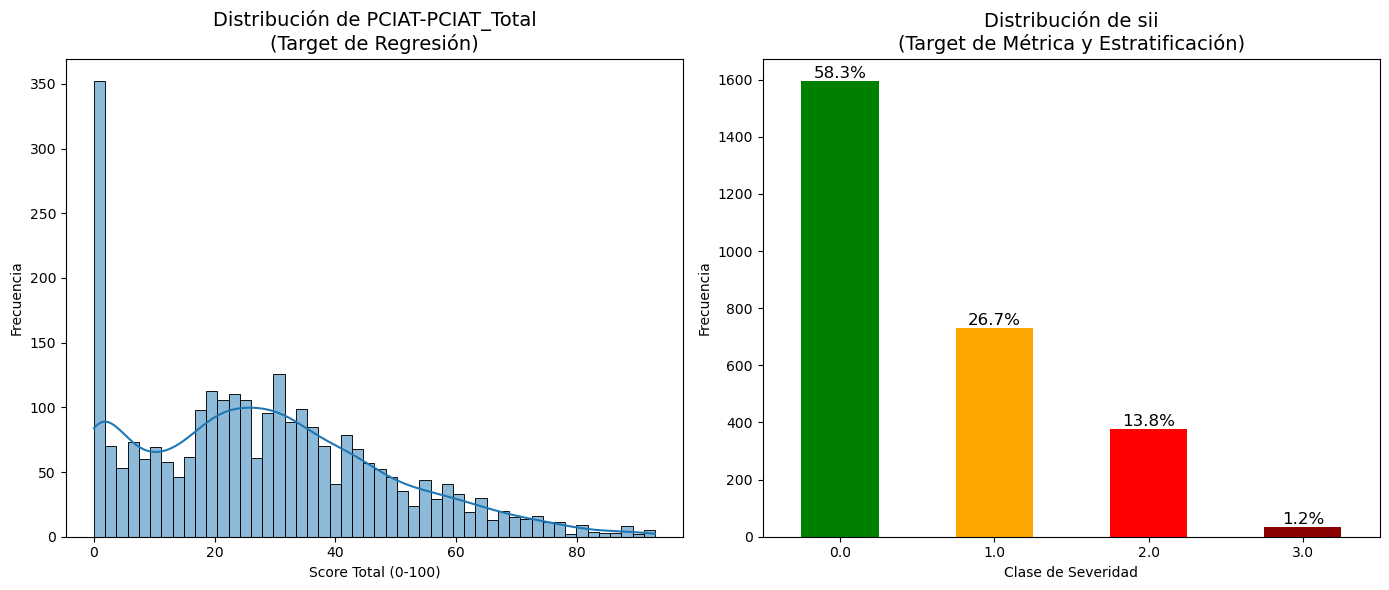


--- Distribución de Clases SII (Target de Métrica) ---
sii
0.0    58.260234
1.0    26.681287
2.0    13.815789
3.0     1.242690
Name: proportion, dtype: float64


In [6]:
# --- 4.2 EDA: Análisis de las Variables Objetivo ---

# Filtramos las filas donde los targets son nulos (común en el 'train.csv')
train_targets = train.dropna(subset=[TARGET, SII_TARGET])

# Gráfico 1: Target de Regresión (Score)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_targets[TARGET], kde=True, bins=50)
plt.title(f"Distribución de {TARGET}\n(Target de Regresión)", fontsize=14)
plt.xlabel("Score Total (0-100)")
plt.ylabel("Frecuencia")

# Gráfico 2: Target de Métrica (Clase)
plt.subplot(1, 2, 2)
ax = train_targets[SII_TARGET].value_counts().sort_index().plot(
    kind='bar', 
    color=['green', 'orange', 'red', 'darkred']
)
plt.title(f"Distribución de {SII_TARGET}\n(Target de Métrica y Estratificación)", fontsize=14)
plt.xlabel("Clase de Severidad")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

# Añadir porcentajes al gráfico de barras
total = len(train_targets)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, color='black')

plt.tight_layout()
plt.show()

print("\n--- Distribución de Clases SII (Target de Métrica) ---")
print(train_targets[SII_TARGET].value_counts(normalize=True).sort_index() * 100)

## 4. EDA: Conclusiones del Análisis de Objetivo

1.  **Target de Regresión (`PCIAT-PCIAT_Total`):** El histograma muestra que los datos no siguen una distribución normal. Están **fuertemente sesgados a la izquierda**, con una gran acumulación de *scores* bajos y en cero. Esto sugiere que un modelo de regresión simple (como Regresión Lineal) fallaría. Un modelo basado en árboles (`LightGBM`) que pueda manejar distribuciones no lineales será una mejor primera opción, además nos ayudaría con las características categóricas.

2.  **Target de Métrica (`sii`):** La distribución de clases es **extremadamente desbalanceada**. La **Clase 3 ("Severo") representa solo el 1.2%**.

**Estrategia:**
* No podemos usar una validación cruzada (`KFold`) simple, ya que algunos *folds* podrían no tener *ningún* ejemplo de la Clase 3. Por lo tanto, usaremos **`StratifiedKFold`**.
* Dado el desbalance, es muy probable que nuestro modelo ignore a la Clase 3. Para combatir esto, exploraremos técnicas de **aumentación de datos**, específicamente **sobremuestreo (oversampling)** de las clases raras (`2` y `3`).

## 5. Ingeniería de Características (Parquet - Plan de Agregación y Limpieza)

Vamos a analizar la segunda fuente de datos: las **series temporales (Parquet)**.

Estos archivos contienen mediciones de alta frecuencia (acelerómetro, luz, etc.). No podemos usar estos datos en bruto directamente en un modelo `LightGBM`.

**Objetivo:** vamos a "aplanar" o "colapsar" estas filas por sujeto en **una sola fila de *features* estadísticas** que resuma el comportamiento de ese sujeto.

**Analisis `non_wear_flag`**
Los datos de actigrafía incluyen una columna `non_wear_flag` (0 = usando, 1 = no usando). Calcular la media de `enmo` sobre datos que incluyen `non_wear_flag == 1` (dispositivo en la mesa) contaminaría las *features* y las haría inútiles.

**Estrategia de Agregación:**
Calcularemos un conjunto de agregados estadísticos para cada señal (`X`, `Y`, `Z`, `enmo`, `anglez`, `light`). Nuestro conjunto de `STATS` incluirá:

1.  **Estadísticas de Tendencia Central y Dispersión (`mean`, `std`, `min`, `max`):**
    * **Por qué:** Son las "vitales" básicas. Nos dicen el nivel *promedio* de actividad (`enmo_mean`), la *variabilidad* (`enmo_std`) y los *extremos* (`enmo_max`).

2.  **Estadísticas de Forma (`skew`, `kurtosis`):**
    * **Por qué:** Describen la *naturaleza* de la actividad.
    * `skew` (Sesgo): ¿La actividad ocurre en picos cortos y explosivos (sesgo positivo) o es más constante (sesgo cero)?
    * `kurtosis` (Curtosis): ¿Qué tan "puntiagudos" son los datos? Un valor alto significa que el sujeto pasa la mayor parte del tiempo quieto (`enmo=0`) pero con ráfagas muy extremas, en lugar de un movimiento moderado constante.

3.  **Cuantiles (`q25`, `q75`):**
    * **Por qué:** Son robustos a *outliers*. El rango intercuartílico (IQR = q75 - q25) nos da el "rango de comportamiento normal" del 50% central de las mediciones, ignorando picos anómalos.

4.  **Estadísticas de Diferencia (`diff_mean`, `diff_std`):**
    * **Por qué:** Esta es una *feature* avanzada que mide la **"tasa de cambio"** o "nerviosismo" de la señal (la diferencia entre un paso de tiempo y el siguiente).
    * `anglez_diff_std` alto: El sujeto cambia de postura de brazo constantemente.
    * `anglez_diff_std` bajo: El sujeto mantiene el brazo en la misma postura por largos períodos (ej. durmiendo, o usando un computador).

In [7]:
# --- 5.1 Ingeniería de Características (Parquet) ---
# Esta celda ejecutará el procesamiento en CPU (CON FILTRADO) y guardará los resultados.

# Cargamos el DF completo primero, LUEGO verificamos si 'non_wear_flag' existe,
# para manejar los archivos Parquet con esquemas inconsistentes.

# 1. Definir las columnas que queremos procesar
SEL_COLS = ["X", "Y", "Z", "enmo", "anglez", "light"]

# 2. Función para procesar un solo archivo parquet
def process_file_pandas(id_path):
    id_str = id_path.name.split('=')[1]
    
    try:
        # Cargar el DF COMPLETO, sin especificar 'columns'.
        df_full = pd.read_parquet(id_path / 'part-0.parquet')
        
        # AHORA, verificamos si 'non_wear_flag' existe en el DF cargado.
        if 'non_wear_flag' in df_full.columns:
            # Si existe, la usamos para filtrar
            pct_non_wear = df_full["non_wear_flag"].mean()
            df_wear = df_full[df_full["non_wear_flag"] == 0].copy()
        else:
            # Si no existe, es un hallazgo: este archivo no tiene la columna.
            # Asumimos que todos los datos son "wear data".
            pct_non_wear = 0.0 # 0% de datos "non-wear"
            df_wear = df_full.copy() # Procesamos el dataframe completo

        # --- Agregación ---
        # Si el df_wear está vacío (ej. el sujeto NUNCA usó el reloj)
        if df_wear.empty:
             return {'id': id_str, 'pct_non_wear': 1.0} # 100% non-wear

        # Diccionario para guardar las features
        feats_dict = {'id': id_str, 'pct_non_wear': pct_non_wear}
        feats_dict["count"] = len(df_wear)
        
        # Iteramos y calculamos stats
        for col in SEL_COLS:
            # Verificación extra: ¿existe la columna de datos (ej. 'light')?
            if col in df_wear.columns:
                col_data = df_wear[col]
                feats_dict[f"{col}_mean"] = col_data.mean()
                feats_dict[f"{col}_std"] = col_data.std()
                feats_dict[f"{col}_min"] = col_data.min()
                feats_dict[f"{col}_max"] = col_data.max()
                feats_dict[f"{col}_skew"] = col_data.skew()
                feats_dict[f"{col}_kurt"] = col_data.kurt()
                feats_dict[f"{col}_q25"] = col_data.quantile(0.25)
                feats_dict[f"{col}_q75"] = col_data.quantile(0.75)
                feats_dict[f"{col}_diff_mean"] = col_data.diff().mean()
                feats_dict[f"{col}_diff_std"] = col_data.diff().std()
            else:
                # Si una columna como 'light' no existe en este archivo,
                # la rellenamos con ceros.
                for stat in ["mean", "std", "min", "max", "skew", "kurt", "q25", "q75", "diff_mean", "diff_std"]:
                    feats_dict[f"{col}_{stat}"] = 0
            
        return feats_dict
    
    except Exception as e:
        print(f"Error fatal procesando {id_str}: {e}")
        return None

# 3. Función principal
def build_features_df_pandas(series_dir, desc="Procesando Parquet"):
    print(f"Iniciando procesamiento para: {series_dir}")
    id_paths = list(series_dir.glob('id=*'))
    all_features = []
    
    for id_path in tqdm(id_paths, desc=desc):
        features = process_file_pandas(id_path)
        if features:
            all_features.append(features)
            
    df_parquet_features = pd.DataFrame(all_features).fillna(0)
    return df_parquet_features

# --- 5.2 Ejecución (El paso lento) ---
print("--- Iniciando Procesamiento de Features Parquet ---")

# Usamos un 'try...except' para cargar si ya existen
try:
    train_parquet_features = pd.read_csv(DATA_DIR / 'train_parquet_features.csv')
    test_parquet_features = pd.read_csv(DATA_DIR / 'test_parquet_features.csv')
    print("Features Parquet cargadas desde archivos CSV guardados.")
    
except FileNotFoundError:
    print("Archivos CSV de features no encontrados. Iniciando procesamiento desde Parquet...")
    
    train_series_dir = DATA_DIR / 'series_train.parquet'
    train_parquet_features = build_features_df_pandas(train_series_dir, desc="Train Parquet")

    test_series_dir = DATA_DIR / 'series_test.parquet'
    test_parquet_features = build_features_df_pandas(test_series_dir, desc="Test Parquet")

    # Guardar los resultados para no repetir este paso
    train_parquet_features.to_csv(DATA_DIR / 'train_parquet_features.csv', index=False)
    test_parquet_features.to_csv(DATA_DIR / 'test_parquet_features.csv', index=False)
    print("\n--- ¡Procesamiento de Parquet Completado! ---")

print(f"Train parquet features shape: {train_parquet_features.shape}")
print(f"Test parquet features shape: {test_parquet_features.shape}")

--- Iniciando Procesamiento de Features Parquet ---
Features Parquet cargadas desde archivos CSV guardados.
Train parquet features shape: (996, 63)
Test parquet features shape: (2, 63)


## 6. Fusión de Datos y Creación del Dataset Completo

Con el EDA tabular y el procesamiento de Parquet completados, ahora tenemos dos conjuntos de *features*:

1.  `train` (3960, 61): Los datos tabulares originales (demografía, físicos, etc.), limpios de *leakers*.
2.  `train_parquet_features` (996, 63): Los nuevos agregados estadísticos de la actigrafía (X, Y, Z, enmo, etc.), ya limpios de datos `non-wear`.

Vamos a **unir (merge)** estas dos fuentes usando la `id` como clave.

Podemos ver que `train` tabular tiene 3960 filas, pero el de Parquet solo 996. Esto es un hallazgo importante: **solo 996 de los 3960 participantes tienen datos de actigrafía**.

Usaremos un `left join` (unión izquierda) para crear un *dataset* completo. Los 3960 participantes se mantendrán, y aquellos sin datos de actigrafía simplemente tendrán `NaN` en esas 62 nuevas columnas. Esto es esperado y será manejado por el imputador en el siguiente paso.

In [8]:
# --- 6.1 Fusión de Fuentes de Datos ---

# (train, test, train_parquet_features, test_parquet_features ya están en memoria)

print(f"Shape de 'train' tabular ANTES de la unión: {train.shape}")
print(f"Shape de 'train_parquet_features' ANTES de la unión: {train_parquet_features.shape}")

# Unir (merge) las features de parquet a los dataframes principales
# Usamos un 'left' join para mantener a todos los 3960 participantes
train_full = train.merge(train_parquet_features, on=ID_COL, how='left')
test_full = test.merge(test_parquet_features, on=ID_COL, how='left')

# --- 6.2 Actualizar nuestra lista de FEATURES ---
# Ahora tenemos todas las features tabulares + las 62 nuevas features de parquet

# Capturamos las nuevas columnas de parquet (ej. 'count', 'X_mean', 'pct_non_wear'...)
parquet_feature_cols = [col for col in train_parquet_features.columns if col != ID_COL]

# Nuestra lista final de FEATURES es la lista original (58) + las nuevas (62)
FEATURES = FEATURES + parquet_feature_cols

print(f"\nNúmero de features tabulares originales: {len(test.columns) - 1}")
print(f"Número de features parquet añadidas: {len(parquet_feature_cols)}")
print(f"Número TOTAL de features para el modelo: {len(FEATURES)}")

print(f"\nShape de 'train' completo DESPUÉS de la unión: {train_full.shape}")
print(f"Shape de 'test' completo DESPUÉS de la unión: {test_full.shape}")

# Inspeccionar el resultado
print("\nHead del DataFrame 'train' completo (mostrando nulos):")
display(train_full.head())

Shape de 'train' tabular ANTES de la unión: (3960, 61)
Shape de 'train_parquet_features' ANTES de la unión: (996, 63)

Número de features tabulares originales: 58
Número de features parquet añadidas: 62
Número TOTAL de features para el modelo: 120

Shape de 'train' completo DESPUÉS de la unión: (3960, 123)
Shape de 'test' completo DESPUÉS de la unión: (20, 121)

Head del DataFrame 'train' completo (mostrando nulos):


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,sii,pct_non_wear,count,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0,55.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,46.0,64.0,Summer,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,38.0,54.0,Summer,2.0,28.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,31.0,45.0,Winter,0.0,44.0,1.0,0.0,43330.0,-0.316384,0.453665,-1.746094,1.507865,0.665002,-0.164232,-0.68418,-0.010677,0.000018,0.198065,0.016009,0.502698,-2.905339,1.666354,-0.198716,-0.602026,-0.309863,0.400677,0.000003,0.242165,-0.16789,0.58571,-1.048372,1.546979,0.491204,-0.757905,-0.649974,0.204727,0.000014,0.239209,0.047388,0.106353,0.0,4.004276,10.136331,199.77356,0.006432,0.04142,9.289108e-07,0.096142,-10.580416,42.947163,-8

## 7. Preprocesamiento: Manejo de Columnas Categóricas

El `DataFrame` `train_full` está completo, pero no ordenado. Contiene una mezcla de tipos de datos:
* `float64` (ej. `Physical-BMI`)
* `int64` (ej. `Basic_Demos-Age`)
* `object` (ej. `Basic_Demos-Enroll_Season`)

El próximo paso es la **imputación de nulos** (usando `KNNImputer`), pero este método **solo funciona con números**. No puede manejar las columnas de texto (como "Fall", "Summer", etc.).

Por lo tanto, nuestro primer paso de preprocesamiento es identificar todas las columnas de tipo `object` (categóricas) y convertirlas a un formato numérico.

### Estrategia de Codificación: Codificación de Enteros (Label Encoding)

**¿Por qué?**
Esta decisión está directamente ligada a la decisión del modelo elegido, **`LightGBM`**.

1.  **Manejo Nativo:** Los modelos de árbol modernos como `LightGBM` pueden manejar características categóricas codificadas como enteros. Al pasarle la lista de estas columnas, el modelo no las trata como números continuos (es decir, no asume que "Summer" (1) es mayor que "Fall" (0)).
2.  **Mejor Rendimiento:** En lugar de hacer divisiones numéricas (`Season < 2`), `LightGBM` encuentra la **agrupación óptima** (ej. `(Fall, Winter) vs (Spring, Summer)`). Esto es más eficiente y potente que el `OneHotEncoder`, que obliga al árbol a hacer múltiples divisiones para lograr el mismo resultado.
3.  **Eficiencia:** `OneHotEncoder` "explota" el número de *features* (añadiendo muchas columnas), lo que hace al modelo más lento y propenso al *overfitting*. Nuestro propuesta mantiene el número de *features* en 120.

En la siguiente celda, aplicaremos esta codificación.

In [9]:
# --- 7.1 Codificación de Features Categóricas ---

print(f"Número de features ANTES de este paso: {len(FEATURES)}")
print(f"Tipos de datos en 'train_full' (antes):\n{train_full[FEATURES].dtypes.value_counts()}")

# 1. Identificar todas las features que son de tipo 'object' (texto)
#    Usamos 'test_full' como referencia, ya que 'train_full' tiene nulos extra
cat_features = test_full[FEATURES].select_dtypes(include='object').columns

print(f"\nSe identificaron {len(cat_features)} features categóricas (tipo 'object'):")
print(cat_features.tolist())

# 2. Convertir estas columnas en 'train' y 'test'
#    Es importante hacerlo en ambos al mismo tiempo para asegurar
#    que los códigos (ej. "Fall" = 1) sean consistentes.
for col in cat_features:
    # Convertir a tipo 'category'
    train_full[col] = train_full[col].astype('category')
    test_full[col] = test_full[col].astype('category')

# 3. Guardar los nombres de las categóricas para LightGBM
#    (LightGBM necesita saber qué columnas tratar como categorías,
#     incluso si son números)
categorical_cols_for_model = cat_features.tolist()

print("\n--- ¡Codificación Completada! ---")
print(f"Tipos de datos en 'train_full' (después):\n{train_full[FEATURES].dtypes.value_counts()}")
print(f"\nHead de 'train_full':")
display(train_full.head())

Número de features ANTES de este paso: 120
Tipos de datos en 'train_full' (antes):
float64    108
object      10
int64        2
Name: count, dtype: int64

Se identificaron 10 features categóricas (tipo 'object'):
['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season', 'PAQ_C-Season', 'SDS-Season', 'PreInt_EduHx-Season']

--- ¡Codificación Completada! ---
Tipos de datos en 'train_full' (después):
float64     108
category     10
int64         2
Name: count, dtype: int64

Head de 'train_full':


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,sii,pct_non_wear,count,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0,55.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,46.0,64.0,Summer,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,38.0,54.0,Summer,2.0,28.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,31.0,45.0,Winter,0.0,44.0,1.0,0.0,43330.0,-0.316384,0.453665,-1.746094,1.507865,0.665002,-0.164232,-0.68418,-0.010677,0.000018,0.198065,0.016009,0.502698,-2.905339,1.666354,-0.198716,-0.602026,-0.309863,0.400677,0.000003,0.242165,-0.16789,0.58571,-1.048372,1.546979,0.491204,-0.757905,-0.649974,0.204727,0.000014,0.239209,0.047388,0.106353,0.0,4.004276,10.136331,199.77356,0.006432,0.04142,9.289108e-07,0.096142,-10.580416,42.947163,-8

## 8. Preprocesamiento: Imputación de Nulos con KNNImputer

Al principio del EDA encontramos que los datos faltan en "bloques" y que tenemos *features* "ancla" completas.

**Nuestra Estrategia: `KNNImputer`**
No usaremos una media/mediana simple. Usaremos `KNNImputer` (Imputador de K-Vecinos Cercanos).

**¿Cómo funciona?**
1.  Para rellenar un `NaN` (ej. el `Physical-BMI` de un sujeto), el imputador buscará los "k" (ej. 5) otros sujetos en el *dataset* que sean **más similares** a él, basándose en las columnas que *sí* están completas (nuestras "anclas" como `Basic_Demos-Age` y `Basic_Demos-Sex`).
2.  Luego, tomará el **promedio** del `Physical-BMI` de esos 5 vecinos y lo usará para rellenar el hueco.

Esto es metodológicamente muy superior, ya que el `BMI` imputado para un niño de 8 años será diferente al de un adulto de 18, porque sus "vecinos" serán diferentes.

**Pasos en la siguiente celda:**
1.  Convertir nuestras 10 columnas `category` a sus códigos numéricos (`.cat.codes`). Pandas asignará `-1` a los `NaN`.
2.  Definir un `StandardScaler()` (escalar los datos es una buena práctica para que `KNNImputer` funcione bien).
3.  Definir `KNNImputer()`.
4.  Ajustar el *pipeline* de imputación **solo en los datos de `train`** y luego usarlo para transformar `train` y `test`.

In [10]:
# --- 8.1 Conversión de Categorías a Códigos Numéricos ---

print(f"Tipos de datos ANTES de .cat.codes:\n{train_full[FEATURES].dtypes.value_counts()}")

# Convertir las 10 columnas 'category' a sus códigos enteros.
# pandas asigna -1 a los valores NaN, lo cual KNNImputer manejará.
for col in categorical_cols_for_model:
    train_full[col] = train_full[col].cat.codes
    test_full[col] = test_full[col].cat.codes

print(f"\nTipos de datos DESPUÉS de .cat.codes (todo numérico):\n{train_full[FEATURES].dtypes.value_counts()}")

# --- 8.2 Ejecución de KNNImputer ---

print("\nIniciando KNNImputer...")

# 1. Inicializar los componentes
# Usaremos 5 vecinos, un número estándar robusto.
imputer = KNNImputer(n_neighbors=5, weights='uniform')
scaler = StandardScaler() # Escalar es importante para KNN

# 2. Crear un pipeline de preprocesamiento simple
# (No usamos el objeto Pipeline de sklearn por la complejidad, 
# pero aplicamos los pasos manualmente)

# 3. Escalar y ajustar el Imputador
#    AJUSTAMOS (FIT) SÓLO EN TRAIN para evitar fuga de datos
print("Ajustando Scaler e Imputer en datos de 'train'...")
scaler.fit(train_full[FEATURES])
train_scaled = scaler.transform(train_full[FEATURES])

imputer.fit(train_scaled)

# 4. Transformar (Imputar) ambos datasets
print("Transformando (imputando) 'train'...")
train_imputed_scaled = imputer.transform(train_scaled)

print("Transformando (imputando) 'test'...")
test_scaled = scaler.transform(test_full[FEATURES]) # Escalar test
test_imputed_scaled = imputer.transform(test_scaled) # Imputar test

# 5. Re-invertir la escala para tener datos interpretables
print("Revirtiendo escalado...")
train_imputed = scaler.inverse_transform(train_imputed_scaled)
test_imputed = scaler.inverse_transform(test_imputed_scaled)

# --- 8.3 Reconstrucción de DataFrames ---

print("Reconstruyendo DataFrames...")
# Convertir de arrays de numpy de vuelta a DataFrames de pandas
train_imputed_df = pd.DataFrame(train_imputed, columns=FEATURES)
test_imputed_df = pd.DataFrame(test_imputed, columns=FEATURES)

# Para LightGBM, es crucial que las categóricas sean de tipo 'int'
for col in categorical_cols_for_model:
    # Redondeamos (KNN puede devolver 1.99 para un código 2) y convertimos a int
    train_imputed_df[col] = train_imputed_df[col].round().astype(int)
    test_imputed_df[col] = test_imputed_df[col].round().astype(int)

# --- 8.4 Verificación Final ---
print("\n--- ¡Imputación Completada! ---")
print("Verificando nulos en 'train_imputed_df':")
null_counts = train_imputed_df.isnull().sum().sum()
print(f"Total de valores nulos: {null_counts}")

if null_counts == 0:
    print("¡Éxito! El dataset está 100% limpio y listo para el modelado.")
else:
    print("¡Error! Aún quedan nulos en el dataset.")

print("\nHead del DataFrame imputado:")
display(train_imputed_df.head())

Tipos de datos ANTES de .cat.codes:
float64     108
category     10
int64         2
Name: count, dtype: int64

Tipos de datos DESPUÉS de .cat.codes (todo numérico):
float64    108
int8        10
int64        2
Name: count, dtype: int64

Iniciando KNNImputer...
Ajustando Scaler e Imputer en datos de 'train'...
Transformando (imputando) 'train'...
Transformando (imputando) 'test'...
Revirtiendo escalado...
Reconstruyendo DataFrames...

--- ¡Imputación Completada! ---
Verificando nulos en 'train_imputed_df':
Total de valores nulos: 0
¡Éxito! El dataset está 100% limpio y listo para el modelado.

Head del DataFrame imputado:


,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,pct_non_wear,count,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std
0,0,5.0,0.0,3,51.0,0,16.877316,46.00,50.80,21.8,80.0,82.4,125.2,-1,3.6,4.6,40.2,0,0.0,0.0,13.58,1.8,12.58,1.6,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,0,2.0,2.668550,16.87920,932.498,1492.000,8.25598,41.5862,13.81770,3.061430,9.213770,1.0,24.43490,8.89536,38.91770,19.54130,32.69090,-1,1.7500,-1,2.718,-1,31.8,45.8,0,3.0,0.0,294390.0,-0.009918,0.564455,-1.954757,1.619902,0.057968,-0.896450,-0.480774,0.436177,0.000001,0.198430,-0.009595,0.478599,-2.373566,2.227239,-0.078658,-0.384852,-0.341866,0.308546,0.000004,0.260509,-0.058665,0.533076,-1.023244,1.999065,0.074054,-0.708830,-0.522009,0.372943,3.180565e-06,0.236403,0.061226,0.129917,0.0,3.386539,7.537071,106.905442,0.007679,0.058407,3.417396e-07,0.123631,-4.667761,37.220493,-89.746280,89.457033,0.019432,-0.410738,-35.143817,23.074758,0.000384,15.732671,20.583634,82.565762,0.0,2299.479980,23.502734,1018.997665,1.740919,11.539087,-0.000536,41.079184
1,2,9.0,0.0,-1,66.8,0,14.035590,48.00,46.00,22.0,75.0,70.0,122.0,-1,6.2,10.2,24.2,0,3.0,0.0,16.36,1.4,15.98,1.6,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,3,2.0,2.579490,14.03710,936.656,1498.650,6.01993,42.0291,12.82540,1.211720,3.970850,1.0,21.03520,14.97400,39.44970,15.41070,27.05520,-1,1.8660,0,2.340,0,46.0,64.0,2,0.0,0.0,326090.0,0.029562,0.557645,-3.023312,2.055674,-0.022168,-0.571547,-0.391474,0.490602,-0.000002,0.186343,-0.014186,0.454186,-2.634720,2.284002,-0.055373,0.084549,-0.303042,0.263818,-0.000002,0.235150,-0.179398,0.565635,-1.174777,2.445676,0.383464,-0.787181,-0.662933,0.226697,-2.506218e-06,0.218754,0.042149,0.119458,0.0,4.571204,9.776559,165.877048,0.001282,0.034762,1.739460e-07,0.103891,-14.045380,41.023225,-89.741815,89.154672,0.249667,-0.491465,-46.988753,13.199843,-0.000188,14.493958,34.087693,155.230585,0.0,2615.439941,12.797677,261.458774,1.687628,11.806896,0.000292,65.645145
2,2,10.0,1.0,0,71.0,0,16.648696,56.50,75.60,28.4,65.0,94.0,117.0,0,5.0,7.0,33.0,0,20.0,1.0,10.20,1.0,14.70,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,-1,1.8,6.379934,16.99786,1061.972,1550.462,16.55350,55.3770,13.90226,3.095602,11.983002,1.2,25.41300,13.41050,48.99706,25.14006,41.96650,-1,1.7180,2,2.170,0,38.0,54.0,2,2.0,0.0,306750.0,0.000456,0.418443,-1.777079,1.888982,0.017480,0.949289,-0.318095,0.254931,0.000002,0.125483,0.065545,0.455555,-2.581237,1.972960,0.027064,0.009029,-0.186494,0.339718,0.000001,0.154702,-0.209908,0.641160,-1.013493,1.840632,0.481794,-0.695473,-0.811756,0.365564,-1.706435e-07,0.142109,0.028737,0.084159,0.0,3.461517,13.103654,327.8077

## 9. Análisis de Componentes Principales (PCA)

Trataremos la alta dimensionalidad y el ruido de nuestras **62 *features* de Parquet**.

**Hallazgos:**
1.  **Correlación:** Es casi seguro que estas 62 *features* (ej. `X_mean`, `X_q25`, `X_std`) están altamente correlacionadas entre sí.
2.  **Ruido:** Muchas de estas *features* pueden ser solo ruido.
3.  **Dimensionalidad:** 120 *features* totales es mucho para un *dataset* de solo ~2700 filas (después de quitar nulos del *target*).

**Elección de (`k`)**
En la siguiente celda, ajustaremos un PCA a los datos de entrenamiento (solo a las 62 *features* de Parquet) y graficaremos la **Varianza Explicada Acumulativa**. Nuestro objetivo es encontrar el "codo": el número de componentes (`k`) que captura la gran mayoría de la información (ej. ~80-90% de la varianza) antes de que la curva se aplane.

Total de features de Parquet a analizar: 62


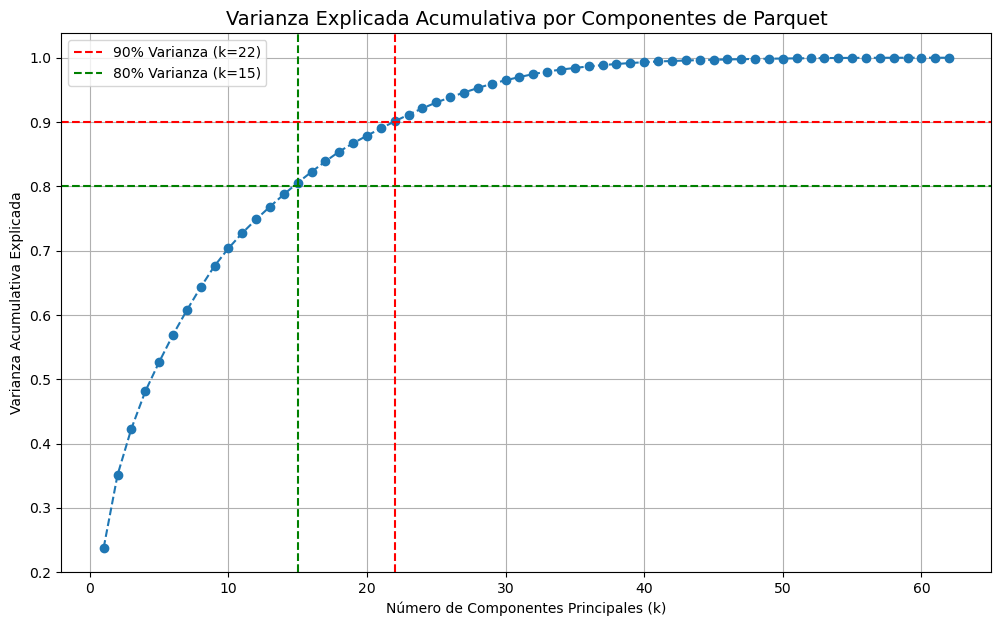


--- Hallazgos del PCA ---
Para capturar el 80% de la varianza, necesitamos k = 15 componentes.
Para capturar el 90% de la varianza, necesitamos k = 22 componentes.

Primeros 20 componentes y su varianza individual:
[0.23795344 0.11315721 0.07210352 0.05772734 0.04571216 0.04244503
 0.03817919 0.03580152 0.03316292 0.02733293 0.02378387 0.02130064
 0.01977705 0.01910079 0.01804907 0.01696725 0.01627066 0.0152864
 0.01299953 0.01169024]


In [11]:
# --- 9.1 Hallazgo de 'k' para PCA (Análisis de Varianza) ---

print(f"Total de features de Parquet a analizar: {len(parquet_feature_cols)}")

# 1. Aislar las features de Parquet de nuestro set de entrenamiento imputado
#    (Usamos 'train_imputed_df')
X_parquet_features = train_imputed_df[parquet_feature_cols]

# 2. Escalar los datos (PCA es sensible a la escala)
#    Ajustamos un scaler SÓLO en estas columnas
scaler_pca = StandardScaler()
X_parquet_scaled = scaler_pca.fit_transform(X_parquet_features)

# 3. Ajustar PCA con todos los componentes para analizar la varianza
#    (n_components=None)
pca_analysis = PCA(n_components=None, random_state=42)
pca_analysis.fit(X_parquet_scaled)

# 4. Calcular la varianza acumulativa
cumulative_variance = np.cumsum(pca_analysis.explained_variance_ratio_)

# --- 9.2 Gráfico de Codo (Scree Plot) ---
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulativa por Componentes de Parquet', fontsize=14)
plt.xlabel('Número de Componentes Principales (k)')
plt.ylabel('Varianza Acumulativa Explicada')
plt.grid(True)

# Añadir marcadores para el 80% y 90% de varianza
k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
plt.axhline(y=0.90, color='r', linestyle='--', label=f'90% Varianza (k={k_90})')
plt.axhline(y=0.80, color='g', linestyle='--', label=f'80% Varianza (k={k_80})')
plt.axvline(x=k_90, color='r', linestyle='--')
plt.axvline(x=k_80, color='g', linestyle='--')
plt.legend()
plt.show()

print("\n--- Hallazgos del PCA ---")
print(f"Para capturar el 80% de la varianza, necesitamos k = {k_80} componentes.")
print(f"Para capturar el 90% de la varianza, necesitamos k = {k_90} componentes.")
print("\nPrimeros 20 componentes y su varianza individual:")
print(pca_analysis.explained_variance_ratio_[:20])

### 9.2 Conclusiones del Análisis PCA y Decisión de 'k'

1.  **El "Codo" (Elbow):** El gráfico muestra un "codo" muy claro alrededor de los 15 componentes. Después de este punto, la curva de varianza acumulativa se aplana, lo que significa que cada componente adicional añade muy poca información nueva.
2.  **Hallazgo Cuantitativo:** Nuestros cálculos confirman esto. Para capturar el **80%** de toda la variabilidad de las 62 *features* de actigrafía, solo necesitamos **k = 15** componentes. Para llegar al 90%, necesitaríamos 7 componentes más (k=22).

**Decisión Metodológica:**
Para nuestra V1, **`k=15`** es la elección óptima. Es un hiperparámetro que hemos descubierto y justificado. Nos permite:
* Reducir drásticamente la dimensionalidad (de 62 a 15 *features*).
* Capturar el 80% de la señal, eliminando el 20% restante (que es probablemente ruido).
* Prevenir el *overfitting* al entregarle al modelo un conjunto de *features* más pequeño y denso.

**Importante:** No aplicaremos el PCA *ahora*. El `pca_analysis` fue solo para *encontrar* el valor de `k`. El `PCA(n_components=15)` real se ajustará (`.fit()`) *dentro* de nuestro bucle de validación cruzada (solo en los datos de entrenamiento de cada *fold*) para prevenir cualquier fuga de datos.

## 10. Ingeniería de Características (FE) Final y Creación del Dataset de Modelado

**Normalización por Grupo de Edad**.

**Hallazgo:** Un `Physical-BMI` de 20 es muy diferente para un niño de 8 años que para uno de 18. El valor en bruto carece de contexto.

**Acción:** Crearemos *features* de "contexto".
1.  Crearemos grupos de edad (ej. "0-8", "9-12", etc.).
2.  Calcularemos el `BMI` *promedio* para cada grupo (basándonos **solo en `train`** para evitar fuga de datos).
3.  Crearemos una nueva *feature* `BMI_norm = BMI_sujeto / BMI_promedio_del_grupo`.
4.  Esto le dice al modelo si el BMI del sujeto es alto o bajo *para su edad*, lo cual es mucho más predictivo. Haremos esto para varias *features* físicas clave.

Finalmente, separaremos nuestros *DataFrames* `X` (features) y `y` (targets) y filtraremos las filas donde el *target* es nulo, dejándo el conjunto de datos listo para el entrenamiento.

In [12]:
# --- 10.1 FE: Creación de Grupos de Edad (Contexto) ---

print("--- Iniciando FE de Grupos de Edad ---")

# 1. Definir los contenedores (bins) de edad
age_bins = [0, 8, 12, 15, 18, 22] # 0-8, 9-12, 13-15, 16-18, 19-22
age_labels = ['0-8', '9-12', '13-15', '16-18', '19-22']

# 2. Crear la columna 'Age_Group' en ambos dataframes
#    (Usamos el 'train_imputed_df')
train_imputed_df['Age_Group'] = pd.cut(
    train_imputed_df['Basic_Demos-Age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

test_imputed_df['Age_Group'] = pd.cut(
    test_imputed_df['Basic_Demos-Age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

# Convertir esta nueva columna a códigos numéricos
# (la trataremos como categórica)
train_imputed_df['Age_Group'] = train_imputed_df['Age_Group'].astype('category').cat.codes
test_imputed_df['Age_Group'] = test_imputed_df['Age_Group'].astype('category').cat.codes

# Añadirla a nuestra lista de features categóricas para el modelo
categorical_cols_for_model.append('Age_Group')

print("Feature 'Age_Group' creada y añadida a las categóricas.")


# --- 10.2 FE: Normalización por Grupo de Edad ---

# 1. Definir las features que queremos normalizar
features_to_norm = [
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
    'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_SMM', 'BIA-BIA_TBW'
]

# 2. Calcular las medias (SOLO en 'train') para evitar fuga de datos
age_group_means = train_imputed_df.groupby('Age_Group')[features_to_norm].mean()

print("\nMedias calculadas por grupo de edad (solo de 'train'):")
display(age_group_means)

# 3. Aplicar la normalización (crear nuevas features)
for col in features_to_norm:
    # Mapear la media del grupo de edad a cada fila
    mean_map_train = train_imputed_df['Age_Group'].map(age_group_means[col])
    
    # Crear la nueva feature normalizada (valor / media del grupo)
    # Rellenamos con 1 por si la media fuera 0
    train_imputed_df[f'{col}_norm_by_age'] = (train_imputed_df[col] / mean_map_train).fillna(1.0)
    
    # Hacer lo mismo para 'test', usando las medias de 'train'
    mean_map_test = test_imputed_df['Age_Group'].map(age_group_means[col])
    test_imputed_df[f'{col}_norm_by_age'] = (test_imputed_df[col] / mean_map_test).fillna(1.0)

# 4. Actualizar nuestra lista de FEATURES
#    (No eliminamos las originales, el árbol decidirá cuál es mejor)
norm_cols = [f'{col}_norm_by_age' for col in features_to_norm]
FEATURES = FEATURES + norm_cols + ['Age_Group']

# --- 10.3 Separación de DataFrames Finales ---
# Ya estamos listos para el modelado.

# Guardamos los dataframes limpios y completos
X = train_imputed_df[FEATURES].copy()
X_test = test_imputed_df[FEATURES].copy()

# Guardamos los targets (quitando nulos)
y = train_full[TARGET].copy()
y_sii = train_full[SII_TARGET].copy()

# **CRÍTICO**: Alinear X, y, y_sii
# Filtramos las filas donde los targets son nulos
valid_target_idx = y.notna() & y_sii.notna()

X = X[valid_target_idx].reset_index(drop=True)
y = y[valid_target_idx].reset_index(drop=True) # Target de Regresión
y_sii = y_sii[valid_target_idx].reset_index(drop=True) # Target de Métrica/CV

# Definimos nuestras features de Parquet para PCA
# (Son las 62 features que creamos antes)
PARQUET_FEATURES = [col for col in train_parquet_features.columns if col != 'id']

print(f"\n{len(norm_cols)} nuevas features de normalización creadas.")
print(f"Número total de features ahora: {len(FEATURES)}")
print("\n--- DataFrames Finales Creados ---")
print(f"X (features de entrenamiento) shape: {X.shape}")
print(f"y (target de regresión) shape: {y.shape}")
print(f"y_sii (target de métrica) shape: {y_sii.shape}")
print(f"X_test (features de test) shape: {X_test.shape}")

--- Iniciando FE de Grupos de Edad ---
Feature 'Age_Group' creada y añadida a las categóricas.

Medias calculadas por grupo de edad (solo de 'train'):


,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_SMM,BIA-BIA_TBW
Age_Group,,,,,,,,,,,
0,17.099176,48.937605,57.041962,3.888374,17.217657,1001.309334,1631.221747,48.915594,11.275849,21.699415,36.152620
1,19.081846,56.242911,84.656709,7.731865,18.867838,1227.621862,2045.229426,73.020864,12.997306,32.864769,53.035794
2,21.707816,63.825420,124.365635,5.698963,21.827179,1440.484406,2425.525642,95.693544,30.189734,46.431621,70.240703
3,23.782908,66.333646,144.390855,5.354074,23.958303,1534.642356,2546.754826,105.722612,42.948124,52.439257,77.607165
4,25.670830,66.095295,157.280227,5.249592,25.561107,1558.692432,2540.178182,108.284269,50.962785,52.889421,79.861712



11 nuevas features de normalización creadas.
Número total de features ahora: 132

--- DataFrames Finales Creados ---
X (features de entrenamiento) shape: (2736, 132)
y (target de regresión) shape: (2736,)
y_sii (target de métrica) shape: (2736,)
X_test (features de test) shape: (20, 132)


## 11. Modelado: Pipeline de Validación Cruzada (CV) Robusta

Nuestro EDA ha revelado dos grandes desafíos:
1.  **Datos Ruidosos:** Los datos están llenos de nulos (que imputamos).
2.  **Datos Desbalanceados:** La clase objetivo `3` es solo el 1.2% de los datos.

**Nuestra Estrategia de Modelado:**
No podemos simplemente entrenar un modelo. Debemos construir un *pipeline* de validación que maneje estos desafíos. Nuestro bucle de CV implementará todos estos hallazgos:

1.  **CV Robusta:** Usaremos `RepeatedStratifiedKFold` (10 pliegues, 5 repeticiones). Esto promediará los resultados de **50 modelos** para obtener un *score* estable que no dependa de un solo "corte" de datos.
2.  **Estratificación:** Estratificaremos usando `y_sii` (las clases 0-3) para asegurar que cada *fold* tenga la proporción correcta de las clases raras.
3.  **PCA (Dentro del Bucle):** Para prevenir la fuga de datos, el `PCA(n_components=15)` (nuestro `k` descubierto) se ajustará (`.fit()`) **solo en los datos de `train` de cada *fold*** y luego transformará los datos de `validation` y `test`.
4.  **Aumentación de Datos (Dentro del Bucle):** Para combatir el desbalance, aplicaremos **Sobremuestreo (Oversampling)** y **Ruido Gaussiano** *solo* a los datos de `train` de cada *fold*.
5.  **Modelo:** Usaremos `LightGBM` como nuestro primer modelo, ya que es rápido y maneja bien las *features* categóricas.

**Objetivo de esta celda:**
Entrenar los 50 modelos y almacenar sus predicciones.
* `oof_predictions`: Las predicciones "fuera de fold" (Out-of-Fold) para nuestro *dataset* de entrenamiento. Las usaremos mas adelante para encontrar nuestros umbrales QWK.
* `test_predictions`: El promedio de las 50 predicciones para el *dataset* de `test`. Esta será nuestra *submission* final.

In [13]:
# --- 11.1 Definición del Pipeline de CV Robusta ---

# --- Constantes del Modelo ---
K_COMPONENTS = 15 # Nuestro 'k'
N_SPLITS = 10     # 10 pliegues
N_REPEATS = 5     # 5 repeticiones
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

# --- 1. Configuración de Validación Cruzada ---
# Usamos RepeatedStratifiedKFold, estratificado por 'y_sii' (nuestro target de métrica)
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, 
    n_repeats=N_REPEATS, 
    random_state=RANDOM_SEED
)

# --- 2. Configuración del Modelo LightGBM ---
# Parámetros base. 'regression_l1' (MAE) es robusto a outliers.
lgb_params = {
    'objective': 'regression_l1',
    'metric': 'rmse',
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': RANDOM_SEED,
    'boosting_type': 'gbdt',
}

# --- 3. Almacenamiento de Predicciones ---
# OOF (Out-of-Fold) para optimizar umbrales
oof_predictions = np.zeros(X.shape[0])
# Predicciones de Test (promediaremos las 50 ejecuciones)
test_predictions = np.zeros(X_test.shape[0])
models = []

display(X.head())

print("--- Iniciando Entrenamiento de CV Robusta ---")
print("Modelo: LightGBM")
print(f"Validación: {N_REPEATS} repeticiones de {N_SPLITS}-Fold CV (Total {N_SPLITS * N_REPEATS} modelos)")
print(f"Features Totales: {X.shape[1]}")
print(f"Features Parquet (antes de PCA): {len(PARQUET_FEATURES)}")
print(f"Features Tabulares: {X.shape[1] - len(PARQUET_FEATURES)}")
print(f"PCA Componentes (k): {K_COMPONENTS}")


# --- 4. Bucle Principal de CV ---
# (Este bucle es nuestro "pipeline" manual para prevenir fugas)
# tqdm nos da una barra de progreso visual
for fold, (train_idx, val_idx) in enumerate(tqdm(
    cv.split(X, y_sii), 
    total=N_SPLITS * N_REPEATS, 
    desc="Entrenando Modelos"
)):
    
    # --- 4.1. División de Datos (Train/Validation) ---
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- 4.2. Pipeline de PCA (Ajustado SOLO en Train) ---
    # Separar features tabulares y de parquet
    X_train_tab = X_train.drop(columns=PARQUET_FEATURES)
    X_val_tab = X_val.drop(columns=PARQUET_FEATURES)
    X_test_tab = X_test.drop(columns=PARQUET_FEATURES)
    
    X_train_par = X_train[PARQUET_FEATURES]
    X_val_par = X_val[PARQUET_FEATURES]
    X_test_par = X_test[PARQUET_FEATURES]

    # Ajustar Scaler y PCA solo en datos de train
    scaler = StandardScaler()
    pca = PCA(n_components=K_COMPONENTS, random_state=RANDOM_SEED)
    
    X_train_par_scaled = scaler.fit_transform(X_train_par)
    X_train_pca = pca.fit_transform(X_train_par_scaled)
    
    # Transformar val y test con el scaler/pca de train
    X_val_par_scaled = scaler.transform(X_val_par)
    X_val_pca = pca.transform(X_val_par_scaled)
    
    X_test_par_scaled = scaler.transform(X_test_par)
    X_test_pca = pca.transform(X_test_par_scaled)

    # Reconstruir DataFrames
    pca_cols = [f'PCA_{i}' for i in range(K_COMPONENTS)]
    X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    X_val_pca_df = pd.DataFrame(X_val_pca, columns=pca_cols, index=X_val.index)
    X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)
    
    X_train_final = pd.concat([X_train_tab, X_train_pca_df], axis=1)
    X_val_final = pd.concat([X_val_tab, X_val_pca_df], axis=1)
    X_test_final = pd.concat([X_test_tab, X_test_pca_df], axis=1)

    # Actualizar lista de categóricas (quitamos las de parquet, añadimos las de PCA)
    categorical_cols_final = [
        col for col in categorical_cols_for_model if col in X_train_final.columns
    ]

    # --- 4.3. Pipeline de Aumentación (SOLO en Train) ---
    X_aug = X_train_final.copy()
    y_aug = y_train.copy()
    
    # 1. Sobremuestreo (Oversampling) de clases raras (2 y 3)
    #    (Nuestro hallazgo: score > 49)
    high_score_idx = y_train[y_train > 49].index
    X_aug = pd.concat([X_aug, X_train_final.loc[high_score_idx]])
    y_aug = pd.concat([y_aug, y_train.loc[high_score_idx]])
    
    # 2. Ruido Gaussiano (leve)
    #    (Solo a las features no categóricas)
    num_cols = [col for col in X_aug.columns if col not in categorical_cols_final]
    noise = np.random.normal(0, 0.01, X_aug[num_cols].shape)
    X_aug[num_cols] = X_aug[num_cols] + noise

    # --- 4.4. Entrenamiento del Modelo ---
    model = lgb.LGBMRegressor(**lgb_params)
    
    model.fit(
        X_aug, 
        y_aug,
        eval_set=[(X_val_final, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(100, verbose=False)],
        categorical_feature=categorical_cols_final
    )
    
    # --- 4.5. Almacenamiento de Predicciones ---
    # Predicciones OOF (en el set de validación limpio)
    oof_predictions[val_idx] = model.predict(X_val_final)
    
    # Predicciones de Test (promediadas)
    test_predictions += model.predict(X_test_final) / (N_SPLITS * N_REPEATS)
    
    models.append(model)

print("\n--- ¡Entrenamiento de CV Completado! ---")
print(f"Shape de predicciones OOF: {oof_predictions.shape}")
print(f"Shape de predicciones de Test: {test_predictions.shape}")

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,pct_non_wear,count,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std,Physical-BMI_norm_by_age,Physical-Height_norm_by_age,Physical-Weight_norm_by_age,BIA-BIA_BMC_norm_by_age,BIA-BIA_BMI_norm_by_age,BIA-BIA_BMR_norm_by_age,BIA-BIA_DEE_norm_by_age,BIA-BIA_FFM_norm_by_age,BIA-BIA_Fat_norm_by_age,BIA-BIA_SMM_norm_by_age,BIA-BIA_TBW_norm_by_age,Age_Group
0,0,5.0,0.0,3,51.0,0,16.877316,46.0,50.8,21.8,80.0,82.4,125.2,-1,3.6,4.6,40.2,0,0.0,0.0,13.58,1.8,12.58,1.6,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,0,2.0,2.668550,16.87920,932.498,1492.000,8.25598,41.5862,13.81770,3.061430,9.213770,1.0,24.4349,8.89536,38.91770,19.54130,32.6909,-1,1.7500,-1,2.718,-1,31.8,45.8,0,3.0,0.0,294390.0,-0.009918,0.564455,-1.954757,1.619902,0.057968,-0.896450,-0.480774,0.436177,1.338309e-06,0.198430,-0.009595,0.478599,-2.373566,2.227239,-0.078658,-0.384852,-0.341866,0.308546,0.000004,0.260509,-0.058665,0.533076,-1.023244,1.999065,0.074054,-0.708830,-0.522009,0.372943,3.180565e-06,0.236403,0.061226,0.129917,0.0,3.386539,7.537071,106.905442,0.007679,0.058407,3.417396e-07,0.123631,-4.667761,37.220493,-89.746280,89.457033,0.019432,-0.410738,-35.143817,23.074758,0.000384,15.732671,20.583634,82.565762,0.0,2299.479980,23.502734,1018.997665,1.740919,11.539087,-0.000536,41.079184,0.987025,0.939972,0.890572,0.686289,0.980342,0.931279,0.914652,0.850162,0.817124,0.900545,0.904247,0
1,2,9.0,0.0,-1,66.8,0,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,-1,6.2,10.2,24.2,0,3.0,0.0,16.36,1.4,15.98,1.6,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,3,2.0,2.579490,14.03710,936.656,1498.650,6.01993,42.0291,12.82540,1.211720,3.970850,1.0,21.0352,14.97400,39.44970,15.41070,27.0552,-1,1.8660,0,2.340,0,46.0,64.0,2,0.0,0.0,326090.0,0.029562,0.557645,-3.023312,2.055674,-0.022168,-0.571547,-0.391474,0.490602,-2.345586e-06,0.186343,-0.014186,0.454186,-2.634720,2.284002,-0.055373,0.084549,-0.303042,0.263818,-0.000002,0.235150,-0.179398,0.565635,-1.174777,2.445676,0.383464,-0.787181,-0.662933,0.226697,-2.506218e-06,0.218754,0.042149,0.119458,0.0,4.571204,9.776559,165.877048,0.001282,0.034762,1.739460e-07,0.103891,-14.045380,41.023225,-89.741815,89.154672,0.249667,-0.491465,-46.988753,13.199843,-0.000188,14.493958,34.087693,155.230585,0.0,2615.439941,12.797677,261.458774,1.687628,11.806896,0.000292,65.645145,0.735547,0.853441,0.543371,0.333618,0.743970,0.762984,0.732754,0.575577,0.305513,0.468912,0.510131,1
2,2,10.0,1.0,0,71.0,0,16.648696,56.5,75.6,28.4,65.0,94.0,117.0,0,5.0,7.0,33.0,0,20.0,1.0,10.20,1.0,14.70,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,-1,1.8,6.379934,16.99786,1061.972,1

--- Iniciando Entrenamiento de CV Robusta ---
Modelo: LightGBM
Validación: 5 repeticiones de 10-Fold CV (Total 50 modelos)
Features Totales: 132
Features Parquet (antes de PCA): 62
Features Tabulares: 70
PCA Componentes (k): 15


Entrenando Modelos:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


Entrenando Modelos:   2%|▏         | 1/50 [00:04<03:51,  4.73s/it]

...

[LightGBM] [Warning] [LightGBM] [Warning] [LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] [LightGBM] [Warning] Met negative value in categorical features, will convert it to NaNMet negative value in categorical features, will convert it to NaN

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


Entrenando Modelos:  98%|█████████▊| 49/50 [04:39<00:06,  6.05s/it]

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN


Entrenando Modelos: 100%|██████████| 50/50 [04:43<00:00,  5.66s/it]


--- ¡Entrenamiento de CV Completado! ---
Shape de predicciones OOF: (2736,)
Shape de predicciones de Test: (20,)


## 12. Optimización de Umbrales y Métrica QWK

Las predicciones (`oof_predictions`) son números continuos (ej. 45.3, 31.2) porque entrenamos un **regresor**.

Debemos convertirilas a clases discretas (`0`, `1`, `2`, `3`) para poder calcular **Kappa Ponderado Cuadrático (QWK).**

**Acción Metodológica:**
Vamos a encontrar los umbrales que mejor traduzcan nuestras predicciones de regresión a clases.

En la siguiente celda, haremos lo siguiente:
1.  Definir una función (`evaluate_predictions`) que tome un conjunto de umbrales (ej. `[30, 50, 80]`) y calcule el *score* QWK.
2.  Usar `scipy.optimize.minimize` para encontrar los 3 umbrales que **maximicen nuestro *score* QWK** en nuestras predicciones `oof_predictions`.
3.  Reportar nuestro *score* final de CV local.
4.  Aplicar estos umbrales optimizados a nuestras `test_predictions` para crear el archivo `submission.csv`.

In [14]:
# --- 12.1 Definición de la Optimización QWK ---

# y (nuestro target de regresión) y y_sii (nuestro target de métrica) ya están en memoria

# Función que convierte la regresión en clases (0,1,2,3)
def round_with_thresholds(raw_preds, thresholds):
    """Aplica umbrales a las predicciones de regresión para obtener clases."""
    return np.digitize(raw_preds, thresholds)

# Función objetivo que 'scipy.optimize' intentará minimizar
# (Minimizamos el QWK *negativo* para maximizar el QWK)
def evaluate_predictions(thresholds, y_true_class, oof_preds_reg):
    """Calcula el QWK para un conjunto de umbrales."""
    # .digitize necesita umbrales ordenados
    thresholds_sorted = np.sort(thresholds)
    
    # Convertir regresión (ej. 45.3) a clase (ej. 1)
    preds_class = round_with_thresholds(oof_preds_reg, thresholds_sorted)
    
    # Calcular QWK
    qwk = cohen_kappa_score(y_true_class, preds_class, weights='quadratic')
    
    # Retornamos el negativo porque 'minimize' busca el valor más bajo
    return -qwk

# --- 12.2 Ejecución de la Optimización ---

print("--- Iniciando Optimización de Umbrales QWK ---")

# oof_predictions (nuestras predicciones de regresión)
# y_sii (nuestras clases verdaderas 0,1,2,3)

# Valores iniciales para los 3 umbrales.
# (Los números no importan mucho, el optimizador los encontrará)
initial_thresholds = [30, 50, 80] 

print(f"Valores iniciales (suposición): {initial_thresholds}")

# Ejecutar el optimizador
# 'minimize' encontrará los mejores 'x' (umbrales)
result = minimize(
    fun=evaluate_predictions,       # La función a minimizar
    x0=initial_thresholds,          # La suposición inicial
    args=(y_sii, oof_predictions),  # Argumentos extra para la función
    method='Nelder-Mead'            # Un algoritmo de optimización robusto
)

# Nuestros umbrales optimizados
optimized_thresholds = np.sort(result.x)
final_cv_qwk_score = -result.fun # Convertir de negativo a positivo

print("\n--- ¡Optimización Completada! ---")
print(f"Score QWK de CV Local Optimizado: {final_cv_qwk_score:.5f}")
print(f"Umbrales óptimos descubiertos: {optimized_thresholds}")

# --- 12.3 Creación del Archivo de Submission ---

# Aplicar nuestros umbrales optimizados a las predicciones de test
submission_predictions = round_with_thresholds(test_predictions, optimized_thresholds)

# Asegurarse de que sean enteros
submission_predictions = submission_predictions.astype(int)

# Crear el DataFrame de submission
submission_df = pd.DataFrame({
    ID_COL: test_full[ID_COL], # Usamos el ID de nuestro test_full
    SII_TARGET: submission_predictions
})

# Guardar
submission_df.to_csv('submission.csv', index=False)

print("\n--- Archivo 'submission.csv' Creado ---")
display(submission_df.head())
print("\nConteo de clases en la submission:")
print(submission_df[SII_TARGET].value_counts(normalize=True).sort_index() * 100)

--- Iniciando Optimización de Umbrales QWK ---
Valores iniciales (suposición): [30, 50, 80]

--- ¡Optimización Completada! ---
Score QWK de CV Local Optimizado: 0.46072
Umbrales óptimos descubiertos: [32.17541152 39.47817537 83.56155693]

--- Archivo 'submission.csv' Creado ---


,id,sii
0,00008ff9,0
1,000fd460,0
2,00105258,0
3,00115b9f,0
4,0016bb22,2



Conteo de clases en la submission:
sii
0    60.0
1    15.0
2    25.0
Name: proportion, dtype: float64
